Description...

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

from   iminuit import Minuit
from   iminuit.cost import LeastSquares
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()
# PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Runs Information

In [2]:
RUNS_INFO =  {  'Ar': [ # July 2026
                        # {'run_number': 16047, 'extra': ''    },
                        # {'run_number': 16057, 'extra': ''    },
                        {'run_number': 16047, 'extra': '20260727'},  # Changes in Irene by Gonzalo
                        {'run_number': 16057, 'extra': '20260727'}
                      ],

                'Xe': [

                      ]
             }

BASE_PATH = '/lhome/ific/c/ccortesp/Data/Cmmssnng/h5/'

# Selected Data

In [3]:
SEL_DICT = {}

print('Loading selected data for:')
for run in RUNS_INFO['Ar']:

    run_id = run['run_number']
    extra  = run['extra']
    # Construct a clean, descriptive dictionary key
    key = f"{run_id}_{extra}" if extra else f"{run_id}"
    print(f"  Run {key}")

    # Load and assign the data, we add the run_id to the dataframes
    # for the global event ID computing
    doro_df = pd.read_hdf(os.path.join(BASE_PATH, 'run_' + key + '_selected.h5'), key='DST/Events')
    doro_df['run_id'] = run_id  

    soph_df = pd.read_hdf(os.path.join(BASE_PATH, 'run_' + key + '_selected.h5'), key='RECO/Events')
    soph_df['run_id'] = run_id

    SEL_DICT[key] = {}
    SEL_DICT[key]['doro_df'] = doro_df
    SEL_DICT[key]['soph_df'] = soph_df

Loading selected data for:
  Run 16047_20260727
  Run 16057_20260727


Construct the _active volume_ mask to avoid the cathode

In [4]:
EXTRA_INFO = {}

for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    doro_df = SEL_DICT[key]['doro_df']

    cath_lim = crudo.tf.get_cathode_limit(doro_df, n_bins=80, step_back=1)
    z_mask    = (doro_df['DT'] >= 0) & (doro_df['DT'] <= cath_lim)
    cath_mask = (doro_df['DT'] > cath_lim)

    EXTRA_INFO[key] = { 'cath_lim': cath_lim, 'AV_Z_mask': z_mask, 'cath_mask': cath_mask }


Run 16047_20260727:
Cathode limit = 513.36 μs

Run 16057_20260727:
Cathode limit = 515.01 μs


# Energy Corrections

In [5]:
# Store fits information
FIT_PARAMETERS = {key: {} for key in SEL_DICT.keys()}
FIT_PARAMETERS

{'16047_20260727': {}, '16057_20260727': {}}

## Fits

### Light Collection

Run 16047_20260727:
Fit: m = (0.15 ± 0.00) PE/μs, b = (54.39 ± 0.23) PE
     χ² / ndof = 6.7255


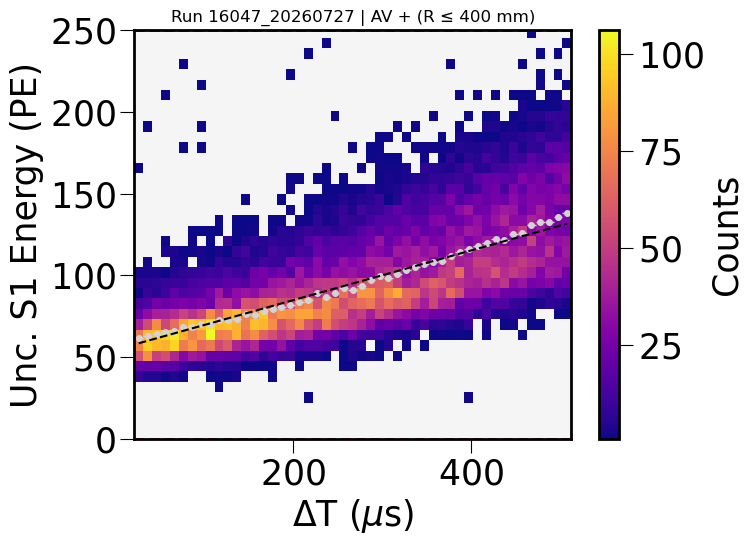

Run 16057_20260727:
Fit: m = (0.16 ± 0.00) PE/μs, b = (52.72 ± 0.28) PE
     χ² / ndof = 3.4465


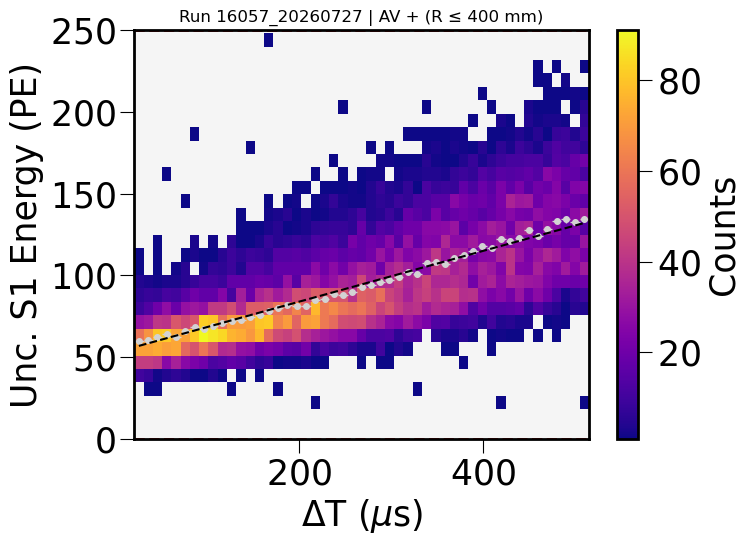

In [6]:
# Global
n_bins  = 50
rad_lim = 400

for key in SEL_DICT.keys():

    print(f"Run {key}:")
    doro_df = SEL_DICT[key]['doro_df']

    # Variables    
    E1 = doro_df['S1e']
    DT = doro_df['DT']
    R  = doro_df['R']

    # Masking
    mask = EXTRA_INFO[key]['AV_Z_mask'] & (R <= rad_lim)
    E1_mask  = E1[mask]
    DT_mask  = DT[mask]

    # 2D histogram
    S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E1_mask, x_bins=n_bins, y_bins=n_bins)                       
    S1e_DT_map         = np.ma.masked_where(S1e_DT_map==0, S1e_DT_map)

    # ----- Linear Fit ----- #
    # Preliminary
    DT_down = 0;    DT_up = DT_mask.max()
    E1_down = 0;    E1_up = 250

    # Filter the data for the fit
    fit_region_mask = (DT_mask >= DT_down) & (DT_mask <= DT_up) & \
                      (E1_mask >= E1_down) & (E1_mask <= E1_up)
    DT_fit = DT_mask[fit_region_mask]
    E1_fit = E1_mask[fit_region_mask]

    # Compute representative values for the fit
    DT_centers, DT_errors, S1e_means, S1e_errors = crudo.ff.prefit_2D(DT_fit, E1_fit, bins=ex)
    # Filter out points with zero error (bins with 1 event)
    valid_points = S1e_errors > 0
    DT_centers = DT_centers[valid_points];      DT_errors  = DT_errors[valid_points]
    S1e_means  = S1e_means[valid_points];       S1e_errors = S1e_errors[valid_points]

    # Definte the cost function + initial guess
    least_squares = LeastSquares(DT_centers, S1e_means, S1e_errors, crudo.ff.linear_func)
    init_guess = [10, S1e_means.min()]
    # print(f'\nInitial guess: m = {init_guess[0]:.4f} PE/μs, b = {init_guess[1]:.4f} PE')

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f'Fit: m = ({popt[0]:.2f} ± {perr[0]:.2f}) PE/μs, b = ({popt[1]:.2f} ± {perr[1]:.2f}) PE')    
    FIT_PARAMETERS[key]["S1e"] = {"m_CV": popt[0], "m_err": perr[0], "b_CV": popt[1], "b_err": perr[1]}

    # Reduced chi-square
    chi2 = m.fval
    ndof = len(DT_centers) - m.nfit
    print(f"     χ² / ndof = {chi2 / ndof:.4f}")

    # ----- Plotting ----- #
    plt.figure(figsize=(8, 6))
    # Data
    plt.pcolormesh(ex, ey, S1e_DT_map.T, cmap='plasma', shading='auto')    
    cbar = plt.colorbar(label='Counts', shrink=1.0)
    # cbar.formatter.set_powerlimits((-3, -3))

    # Fit
    fit_y = crudo.ff.linear_func(DT_centers, *popt)
    plt.errorbar(DT_centers, S1e_means, xerr=DT_errors, yerr=S1e_errors, fmt='o', c='lightgray', ecolor='lightgray', lw=1.0, markersize=4)
    plt.plot(DT_centers, fit_y, c='black', ls='--', lw=1.5, zorder=3)
    plt.axhline(y=E1_up, c='red', ls='--')
    plt.axhline(y=E1_down, c='red', ls='--')

    # ----- Styling ----- #
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.ylabel('Unc. S1 Energy (PE)')
    plt.ylim(E1_down, E1_up)
    plt.title(f'Run {key} | AV + (R ≤ {rad_lim} mm)', fontsize=12, loc='center')

    plt.gca().set_facecolor("whitesmoke")
    plt.tight_layout()
    plt.show() 

### Lifetime

Run 16047_20260727:
Fit: N0 = (22481.62 ± 38.65) PE, τ = (41.01 ± 9.44) ms
     χ² / ndof = 0.9675


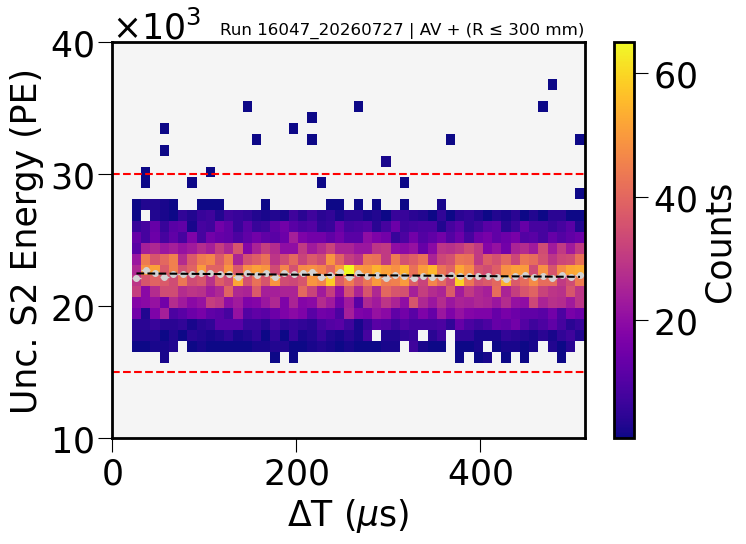

Run 16057_20260727:
Fit: N0 = (22474.16 ± 46.62) PE, τ = (36.08 ± 8.83) ms
     χ² / ndof = 1.0490


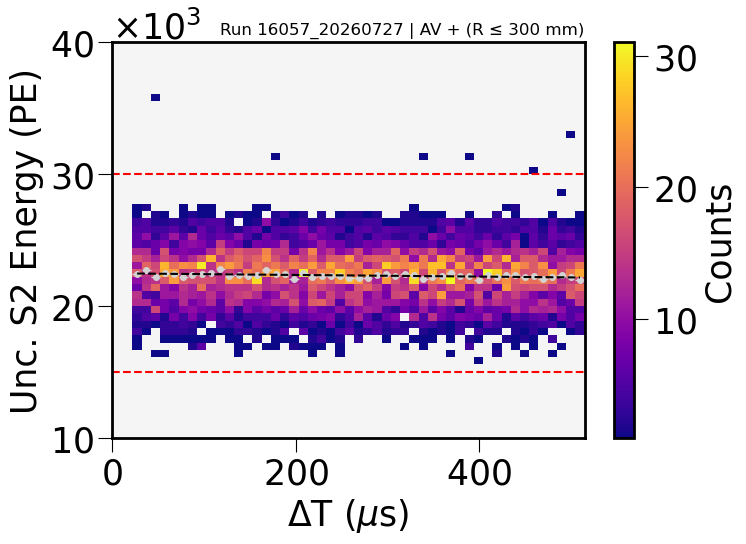

In [7]:
# Global
n_bins  = 50
rad_lim = 300

# Use exponential decay function with b = 0
def exp_bfixed(x, N0, tau):
    return crudo.ff.exponential_decay(x, N0, tau, 0)

for key in SEL_DICT.keys():

    print(f"Run {key}:")
    doro_df = SEL_DICT[key]['doro_df']
        
    # Variables    
    E2 = doro_df['S2e']
    DT = doro_df['DT']
    R  = doro_df['R']

    # Masking
    mask = EXTRA_INFO[key]['AV_Z_mask'] & (R <= rad_lim)
    E2_mask  = E2[mask]
    DT_mask  = DT[mask]

    # 2D histogram: normalized by corrected DAQ data taking time
    S2e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E2_mask, x_bins=50, y_bins=50)                           
    S2e_DT_map         = np.ma.masked_where(S2e_DT_map==0, S2e_DT_map)
    
    # ---- Exponential Fit ----- #
    # Preliminary
    DT_down = DT_mask.min();    DT_up = DT_mask.max()
    E2_down = 15e3;  E2_up = 30e3

    # Filter the data for the fit
    fit_region_mask = (DT_mask >= DT_down) & (DT_mask <= DT_up) & \
                      (E2_mask >= E2_down) & (E2_mask <= E2_up)
    DT_fit = DT_mask[fit_region_mask]
    E2_fit = E2_mask[fit_region_mask]

    # Compute representative values for the fit
    DT_centers, DT_errors, S2e_means, S2e_errors = crudo.ff.prefit_2D(DT_fit, E2_fit, bins=ex)
    # Filter out points with zero error (bins with 1 event)
    valid_points = S2e_errors > 0
    DT_centers = DT_centers[valid_points];      DT_errors  = DT_errors[valid_points]
    S2e_means  = S2e_means[valid_points];       S2e_errors = S2e_errors[valid_points]

    # Definte the cost function + initial guess
    least_squares = LeastSquares(DT_centers, S2e_means, S2e_errors, exp_bfixed)
    init_guess = [S2e_means.max(), (DT_centers.max() - DT_centers.min()) / 2]
    # print(f'\nInitial guess: N0 = {init_guess[0]:.4f} PE, tau = {init_guess[1]:.4f} μs')

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f'Fit: N0 = ({popt[0]:.2f} ± {perr[0]:.2f}) PE, τ = ({popt[1] / 1e3:.2f} ± {perr[1] / 1e3:.2f}) ms')
    FIT_PARAMETERS[key]["S2e"] = {"N0_CV": popt[0], "N0_err": perr[0], "tau_CV": popt[1], "tau_err": perr[1]}
    
    # Reduced chi-square
    chi2 = m.fval
    ndof = len(DT_centers) - m.nfit
    print(f"     χ² / ndof = {chi2 / ndof:.4f}")

    # ----- Plotting ----- #
    plt.figure(figsize=(8, 6))
    # Data
    plt.pcolormesh(ex, ey, S2e_DT_map.T, cmap='plasma', shading='auto')
    cbar = plt.colorbar(label='Counts', shrink=1.0)
    # cbar.formatter.set_powerlimits((-3, -3))

    # Fit
    fit_y = exp_bfixed(DT_centers, *popt)
    plt.errorbar(DT_centers, S2e_means, xerr=DT_errors, yerr=S2e_errors, fmt='o', c='lightgray', ecolor='lightgray', lw=1.0, markersize=4)
    plt.plot(DT_centers, fit_y, c='black', ls='--', lw=1.5, zorder=3)
    # plt.axvline(x=DT_down, c='red', ls='--')
    plt.axhline(y=E2_down, c='red', ls='--', lw=1.5)
    plt.axhline(y=E2_up, c='red', ls='--', lw=1.5)

    # ----- Styling ----- #
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.xlim(0, DT_mask.max())
    plt.ylabel('Unc. S2 Energy (PE)') 
    plt.ylim(10e3, 40e3)
    plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
    plt.title(f'Run {key} | AV + (R ≤ {rad_lim} mm)', fontsize=12, loc='right')

    plt.gca().set_facecolor("whitesmoke")
    plt.tight_layout()
    plt.show() 

In [42]:
FIT_PARAMETERS

{'16047_20260727': {'S1e': {'m_CV': 0.15192485519525079,
   'm_err': 0.0009626626795370248,
   'b_CV': 54.39352997404467,
   'b_err': 0.2321508191943919},
  'S2e': {'N0_CV': 22481.621938666347,
   'N0_err': 38.648545365426735,
   'tau_CV': 41013.942463120344,
   'tau_err': 9442.209355499921}},
 '16057_20260727': {'S1e': {'m_CV': 0.15564513183711348,
   'm_err': 0.001202056533041221,
   'b_CV': 52.723243607879,
   'b_err': 0.2762790059621478},
  'S2e': {'N0_CV': 22474.163836831467,
   'N0_err': 46.62189209030172,
   'tau_CV': 36079.71306835622,
   'tau_err': 8826.115078728644}}}

## Apply Corrections

In [8]:
# Global
n_bins  = 35

# Reference DataFrame for energy map generation
ref_key = '16047_20260727'  
ref_df = SEL_DICT[ref_key]['doro_df'].copy()
CV_fit = [FIT_PARAMETERS[ref_key]['S1e']['m_CV'],  FIT_PARAMETERS[ref_key]['S1e']['b_CV']]
LT_fit = [FIT_PARAMETERS[ref_key]['S2e']['N0_CV'], FIT_PARAMETERS[ref_key]['S2e']['tau_CV']]

print(f"Generating energy map of reference...\nThank you run {ref_key} for your stats")

ref_df = crudo.ef.correct_S2e_LT(ref_df, LT_fit, output_column='S2e_corr_LT')   # S2 energy by lifetime

# Variables
X_ref  = ref_df['X']
Y_ref  = ref_df['Y']
E2_ref = ref_df['S2e_corr_LT']
mask = EXTRA_INFO[ref_key]['AV_Z_mask']

# Generate the energy map normalized to the center
ref_energy_map, x_edges, y_edges = crudo.ef.pt.mapping(X_ref[mask], Y_ref[mask], wei=E2_ref[mask], 
                                                       bin_scale=4, max_limit=crudo.pt.N100_rad, norm=True)

Generating energy map of reference...
Thank you run 16047_20260727 for your stats


In [9]:
for key in SEL_DICT.keys():

    print(f"--- Run {key} ---")
    doro_df  = SEL_DICT[key]['doro_df']
    cath_lim = EXTRA_INFO[key]['cath_lim']
        
    # Apply corrections
    doro_df = crudo.ef.correct_S1e   (doro_df, CV_fit, cath_lim, output_column='S1e_corr')  # S1 energy
    doro_df = crudo.ef.correct_S2e_LT(doro_df, LT_fit, output_column='S2e_corr_LT')         # S2 energy by lifetime
    # Apply S2 energy correction by geometric map
    doro_df = crudo.ef.correct_S2e_map_fixed(doro_df, ref_energy_map, x_edges, y_edges)

--- Run 16047_20260727 ---
--- Run 16057_20260727 ---


## Control Plots

Run 16047_20260727:


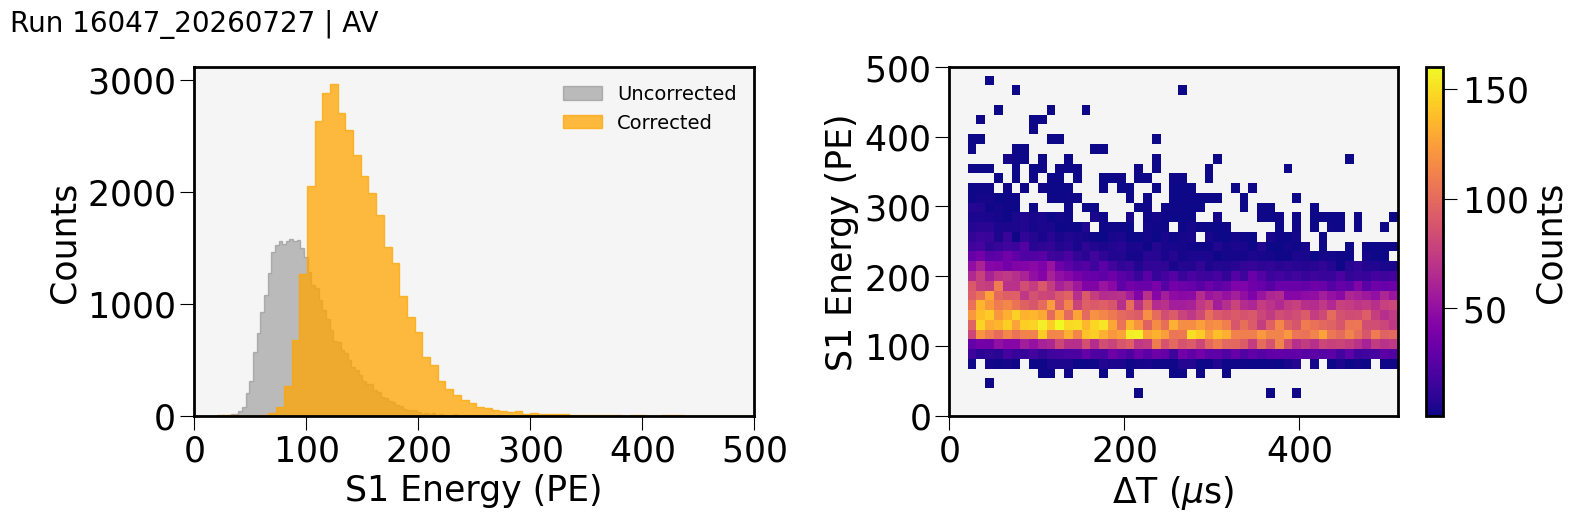

Run 16057_20260727:


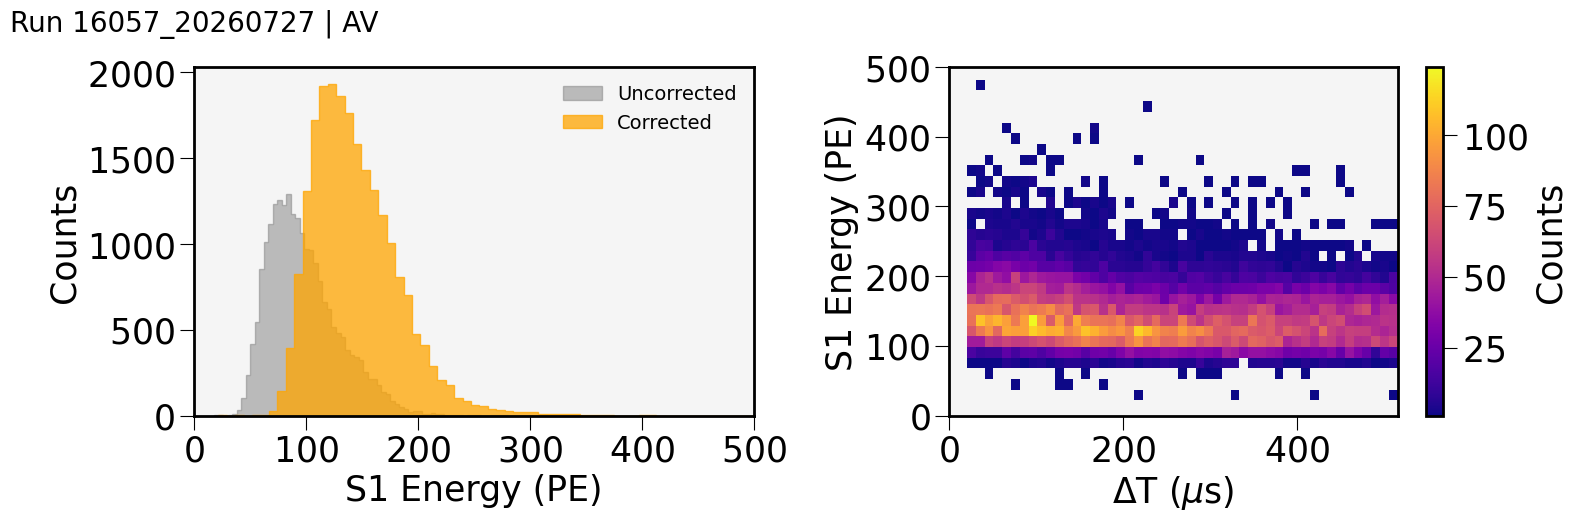

In [10]:
# Global
n_bins = 100
E1_min = 0; E1_max = 0.5e3

for key in SEL_DICT.keys():

    print(f"Run {key}:")
    doro_df = SEL_DICT[key]['doro_df']
    
    # Variables    
    E1      = doro_df['S1e']
    E1_corr = doro_df['S1e_corr']
    DT      = doro_df['DT']

    # Masking
    mask = EXTRA_INFO[key]['AV_Z_mask']
    E1_mask  = E1[mask]
    E1c_mask = E1_corr[mask]
    DT_mask  = DT[mask]

    # 2D histogram: normalized by corrected DAQ data taking time
    S1e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E1c_mask, x_bins=50, y_bins=50)                        
    S1e_DT_map         = np.ma.masked_where(S1e_DT_map == 0, S1e_DT_map)  # Zero values masked

    # ----- Plotting ----- #
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left
    axes[0].hist(E1_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='grey', alpha=0.50, ec='grey', label='Uncorrected')
    axes[0].hist(E1c_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='orange', alpha=0.75, ec='orange', label='Corrected')
    axes[0].set_xlabel('S1 Energy (PE)')
    axes[0].set_xlim(E1_min, E1_max)
    axes[0].set_ylabel('Counts')
    axes[0].legend(loc='upper right', fontsize=14, facecolor='none')
    axes[0].set_facecolor('whitesmoke')

    # Right
    pcm = axes[1].pcolormesh(ex, ey, S1e_DT_map.T, cmap='plasma', shading='auto')
    cbar = fig.colorbar(pcm, ax=axes[1], label='Counts')
    axes[1].set_xlabel('$\Delta$T ($\mu$s)')
    axes[1].set_xlim(0, DT_mask.max())
    axes[1].set_ylim(E1_min, E1_max)
    axes[1].set_ylabel('S1 Energy (PE)')
    axes[1].set_facecolor('whitesmoke')

    # Single title for the figure
    fig.suptitle(f'Run {key} | AV', fontsize=20, x=0, y=0.90, ha='left')

    plt.tight_layout()
    plt.show()

Run 16047_20260727:


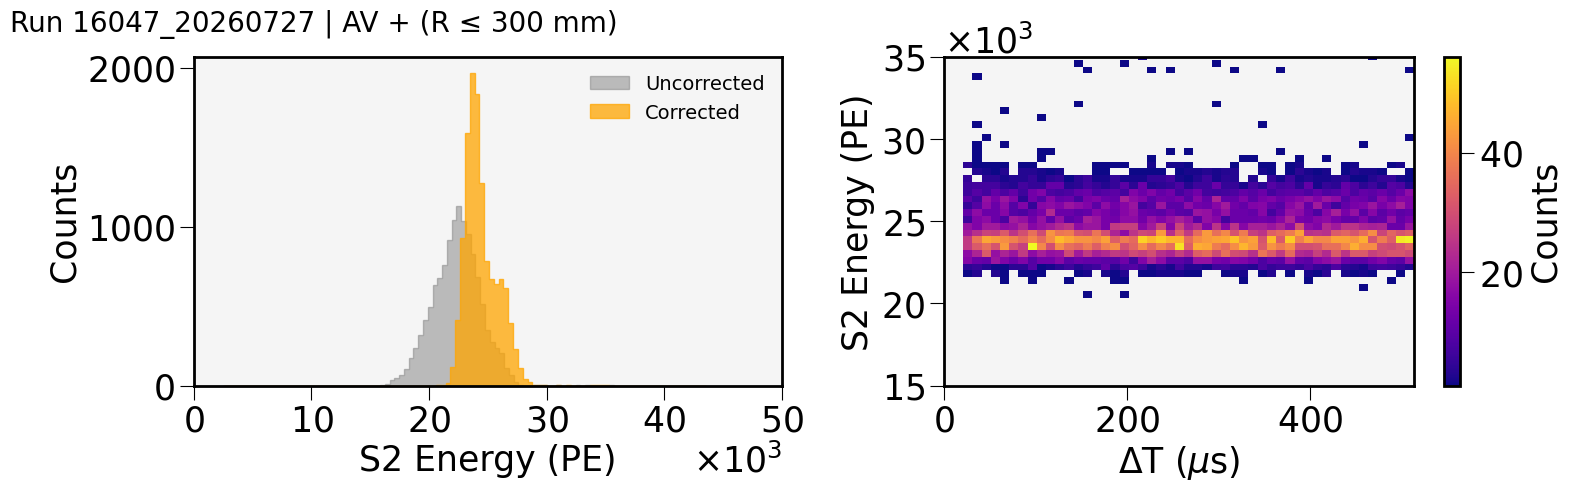

Run 16057_20260727:


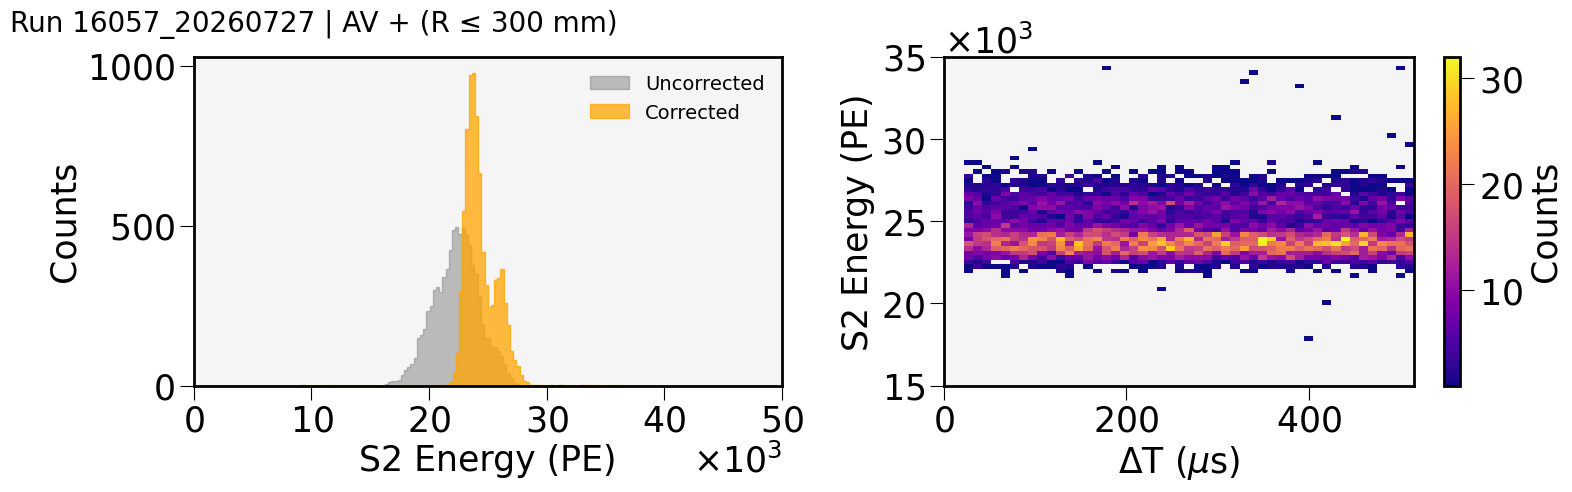

In [11]:
# Global
n_bins = 100
E2_min = 0e3;  E2_max = 50e3
rad_lim = 300

for key in SEL_DICT.keys():

    print(f"Run {key}:")
    doro_df = SEL_DICT[key]['doro_df']
    
    # Variables    
    E2      = doro_df['S2e']
    E2_corr = doro_df['S2e_corr']
    DT      = doro_df['DT']
    R     = doro_df['R']

    # Masking
    mask = (EXTRA_INFO[key]['AV_Z_mask']) & (R <= rad_lim)
    E2_mask = E2[mask]
    E_mask  = E2_corr[mask]
    DT_mask = DT[mask]

    # 2D histogram: normalized by corrected DAQ data taking time
    S2e_DT_map, ex, ey = crudo.pt.hist_2D(DT_mask, E_mask, x_bins=50, y_bins=100)                    
    S2e_DT_map         = np.ma.masked_where(S2e_DT_map == 0, S2e_DT_map)

        # ----- Plotting ----- #
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left
    axes[0].hist(E2_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='grey', alpha=0.50, ec='grey', label='Uncorrected')
    axes[0].hist(E_mask, bins=n_bins, histtype='stepfilled', lw=1.0, color='orange', alpha=0.75, ec='orange', label='Corrected')
    axes[0].set_xlabel('S2 Energy (PE)')
    axes[0].set_xlim(E2_min, E2_max)
    axes[0].set_ylabel('Counts')
    axes[0].ticklabel_format(axis='x', style='sci', scilimits=(3,3))
    axes[0].legend(loc='upper right', fontsize=14, facecolor='none')
    axes[0].set_facecolor('whitesmoke')

    # Right
    pcm = axes[1].pcolormesh(ex, ey, S2e_DT_map.T, cmap='plasma', shading='auto')
    cbar = fig.colorbar(pcm, ax=axes[1], label='Counts')
    axes[1].set_xlabel('$\Delta$T ($\mu$s)')
    axes[1].set_ylim(15e3, 35e3)
    axes[1].set_xlim(0, DT_mask.max())
    axes[1].set_ylabel('S2 Energy (PE)')
    axes[1].ticklabel_format(axis='y', style='sci', scilimits=(3,3))
    axes[1].set_facecolor('whitesmoke')

    # Single title for the figure
    # fig.suptitle(f'Run {key} | AV', fontsize=20, x=0, y=0.85, ha='left')
    fig.suptitle(f'Run {key} | AV + (R ≤ {rad_lim} mm)', fontsize=20, x=0, y=0.85, ha='left')

    plt.tight_layout()
    plt.show()

# Energy Plots

### Active Volume


Run 16047_20260727:


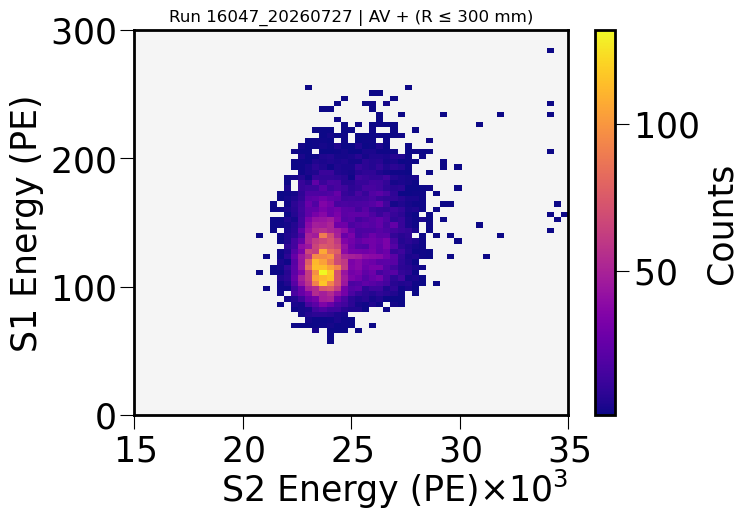


Run 16057_20260727:


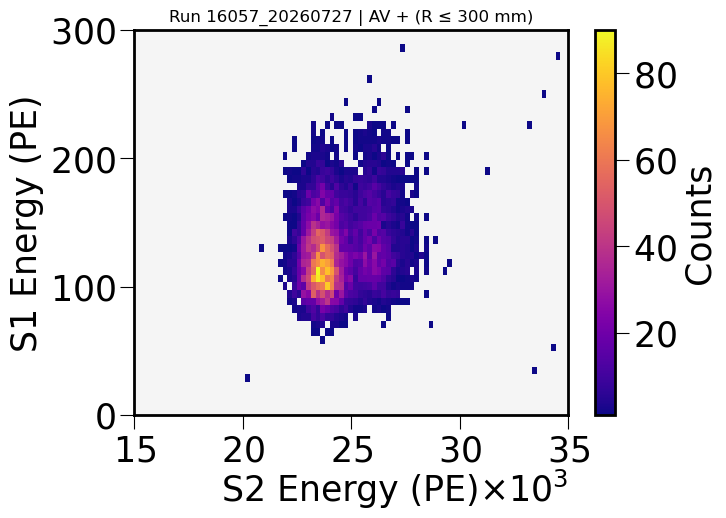

In [28]:
# Global
n_bins = 125
# rad_lim = [500, 400, 300, 200]
rad_lim = [300]

for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    doro_df = SEL_DICT[key]['doro_df']

    # Variables    
    E1 = doro_df['S1e_corr']
    E2 = doro_df['S2e_corr']
    R = np.sqrt(doro_df['X']**2 + doro_df['Y']**2)

    for r_lim in rad_lim:

        # Masking
        mask = (EXTRA_INFO[key]['AV_Z_mask']) & (R <= r_lim)
        E1_mask = E1[mask]
        E2_mask = E2[mask]

        # 2D Histogram
        s1e_s2e_map, ex, ey = np.histogram2d(E2_mask, E1_mask, bins=[n_bins, n_bins])
        s1e_s2e_map         = np.ma.masked_where(s1e_s2e_map==0, s1e_s2e_map)

        # Plot
        plt.pcolormesh(ex, ey, s1e_s2e_map.T, cmap='plasma', shading='auto')
        plt.colorbar(label='Counts')
        plt.xlabel('S2 Energy (PE)')
        plt.ylabel('S1 Energy (PE)')
        plt.xlim(15e3, 35e3)
        plt.ylim(0, 300)
        plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
        plt.title (f'Run {key} | AV + (R ≤ {r_lim} mm)', loc='center', fontsize=12) 

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

### Cathode


Run 16047_20260727:


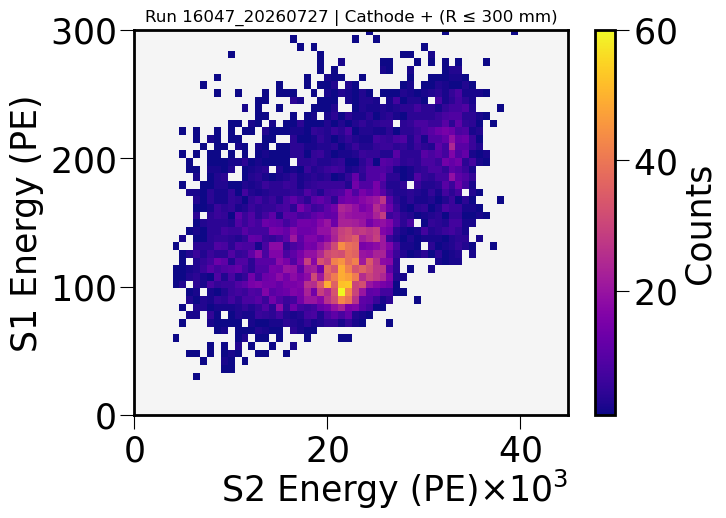


Run 16057_20260727:


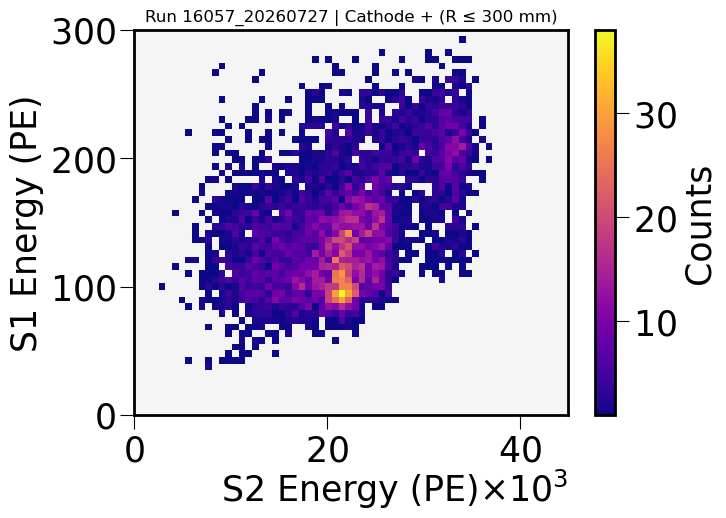

In [32]:
# Global
n_bins = 50
# rad_lim = [500, 400, 300, 200]
rad_lim = [300]

for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    doro_df = SEL_DICT[key]['doro_df']

    # Variables    
    E1 = doro_df['S1e_corr']
    E2 = doro_df['S2e_corr']
    R = np.sqrt(doro_df['X']**2 + doro_df['Y']**2)

    for r_lim in rad_lim:

        # Masking
        mask = (EXTRA_INFO[key]['cath_mask']) & (R <= r_lim)
        E1_mask = E1[mask]
        E2_mask = E2[mask]

        # 2D Histogram
        s1e_s2e_map, ex, ey = np.histogram2d(E2_mask, E1_mask, bins=[n_bins, n_bins])
        s1e_s2e_map         = np.ma.masked_where(s1e_s2e_map==0, s1e_s2e_map)

        # Plot
        plt.pcolormesh(ex, ey, s1e_s2e_map.T, cmap='plasma', shading='auto')
        plt.colorbar(label='Counts')
        plt.xlabel('S2 Energy (PE)')
        plt.ylabel('S1 Energy (PE)')
        plt.xlim(0, 45e3)
        plt.ylim(0, 300)
        plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
        plt.title (f'Run {key} | Cathode + (R ≤ {r_lim} mm)', loc='center', fontsize=12) 

        plt.gca().set_facecolor("whitesmoke")
        plt.show()

# Hit-level

### Active Volume


Run 16047_20260727:


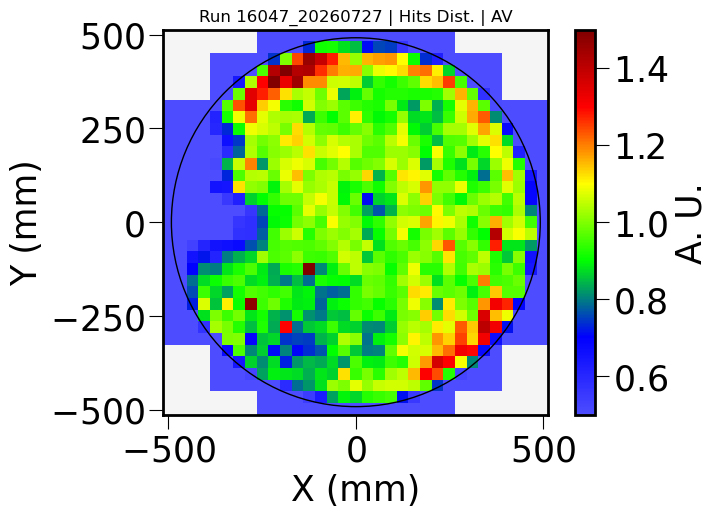


Run 16057_20260727:


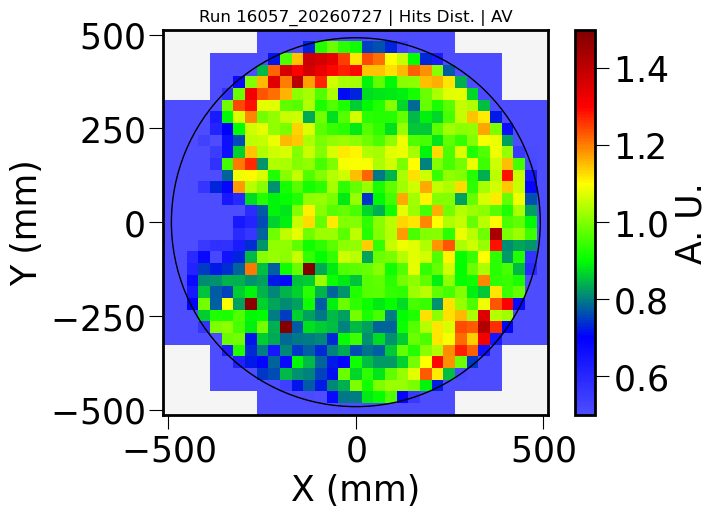

In [36]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    soph_df = SEL_DICT[key]['soph_df']

    # Variables    
    X = soph_df['X']
    Y = soph_df['Y']
    Z = soph_df['Z']

    # Masking
    mask = (Z >= 0) & (Z <= EXTRA_INFO[key]['cath_lim'])    # AV
    X_mask = X[mask]
    Y_mask = Y[mask]

    # Map
    xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=2, max_limit=crudo.pt.N100_rad, pos=True, norm=True)
    xy_map         = np.ma.masked_where(xy_map==0, xy_map)

    # Plot
    plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto', vmin=0.5, vmax=1.5)
    cbar = plt.colorbar(label='A. U.')
    cbar.set_ticks([0.6, 0.8, 1.0, 1.2, 1.4])
    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')
    plt.title (f'Run {key} | Hits Dist. | AV', loc='center', fontsize=12) 

    plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().set_facecolor("whitesmoke")
    plt.show()

### Cathode


Run 16047_20260727:


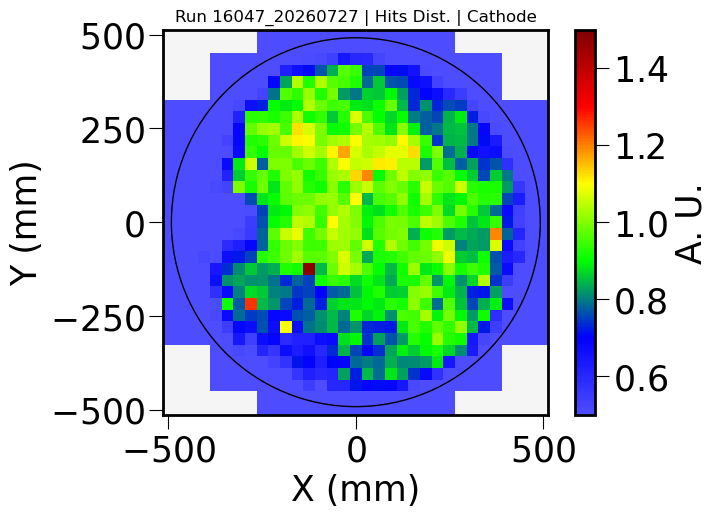


Run 16057_20260727:


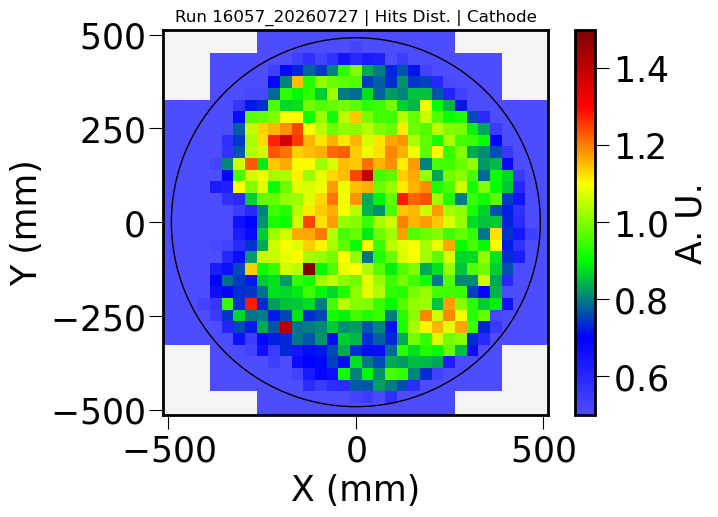

In [37]:
for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    soph_df = SEL_DICT[key]['soph_df']

    # Variables    
    X = soph_df['X']
    Y = soph_df['Y']
    Z = soph_df['Z']

    # Masking
    mask = (Z > EXTRA_INFO[key]['cath_lim'])    # Cathode
    X_mask = X[mask]
    Y_mask = Y[mask]

    # Map
    xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=2, max_limit=crudo.pt.N100_rad, pos=True, norm=True)
    xy_map         = np.ma.masked_where(xy_map==0, xy_map)

    # Plot
    plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto', vmin=0.5, vmax=1.5)
    cbar = plt.colorbar(label='A. U.')
    cbar.set_ticks([0.6, 0.8, 1.0, 1.2, 1.4])
    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')
    plt.title (f'Run {key} | Hits Dist. | Cathode', loc='center', fontsize=12) 

    plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().set_facecolor("whitesmoke")
    plt.show()

# Run Stability

## $S2e$ / NSiPM

In [38]:
SEL_DICT['16047_20260727']['doro_df'].columns

Index(['event', 'time', 's1_peak', 's2_peak', 'nS1', 'nS2', 'S1w', 'S1h',
       'S1e', 'S1t', 'S2w', 'S2h', 'S2e', 'S2q', 'S2t', 'qmax', 'Nsipm', 'DT',
       'Z', 'Zrms', 'X', 'Y', 'R', 'Phi', 'Xrms', 'Yrms', 'run_id', 'S1e_corr',
       'S2e_corr_LT', 'x_bin', 'y_bin', 'S2e_norm_factor', 'S2e_corr'],
      dtype='object')


Run 16047_20260727:
  S2e / # SiPMs = [433.85, 9412.02] PE


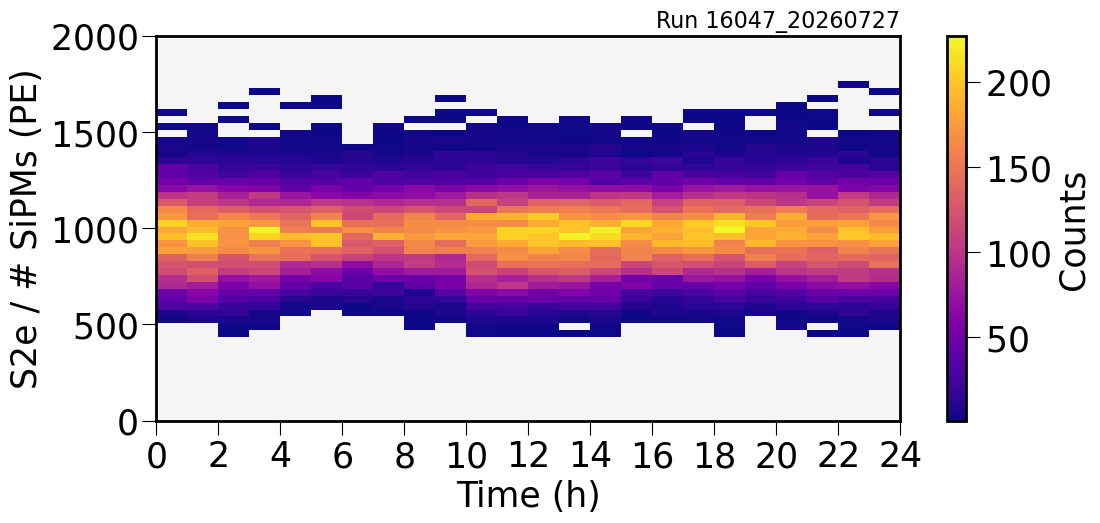


Run 16057_20260727:
  S2e / # SiPMs = [462.45, 4624.84] PE


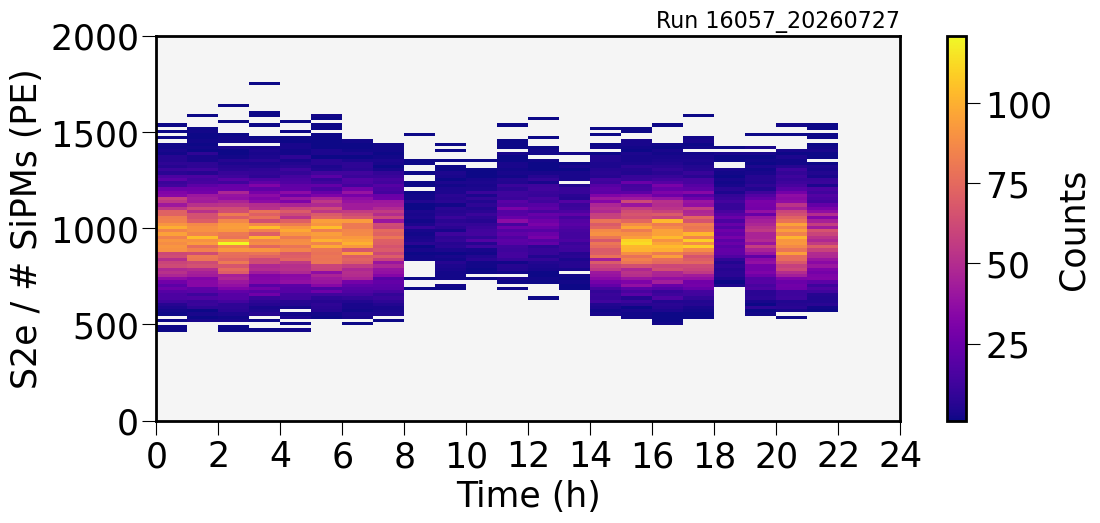

In [47]:
x_bins = 24  # 24 bins, one for each hour
y_bins = 250

for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    doro_df = SEL_DICT[key]['doro_df']

    # Variables
    time = doro_df['time'] - doro_df['time'].min()    # Normalize time to start at 0
    time = (time / 3600).astype(int)                # Convert time to hours
    E2     = doro_df['S2e']
    n_sipm = doro_df['Nsipm']

    # Mask
    mask = (n_sipm > 0) 

    time = time[mask]
    E2     = E2[mask]
    n_sipm = n_sipm[mask]

    y_val = E2 / n_sipm
    print(f"  S2e / # SiPMs = [{y_val.min():.2f}, {y_val.max():.2f}] PE")

    # 2D Histogram
    map_2d, ex, ey = np.histogram2d(time, y_val, bins=[x_bins, y_bins], range=[[0, 24], [y_val.min(), y_val.max()]])
    map_2d         = np.ma.masked_where(map_2d==0, map_2d)

    # Plot
    plt.figure(figsize=(12, 5))
    plt.pcolormesh(ex, ey, map_2d.T, cmap='plasma', shading='auto')
    plt.colorbar(label='Counts')
    plt.xlabel('Time (h)')
    plt.xticks(ticks=np.arange(0, 25, 2), labels=[f"{i}" for i in range(0, 25, 2)])
    plt.ylabel('S2e / # SiPMs (PE)')
    plt.ylim(0, 2e3)
    # plt.ticklabel_format(axis='y', style='sci', scilimits=(-1, 0))
    plt.title (f'Run {key}', loc='right', fontsize=16) 

    plt.gca().set_facecolor("whitesmoke")
    plt.show()


Run 16047_20260727:


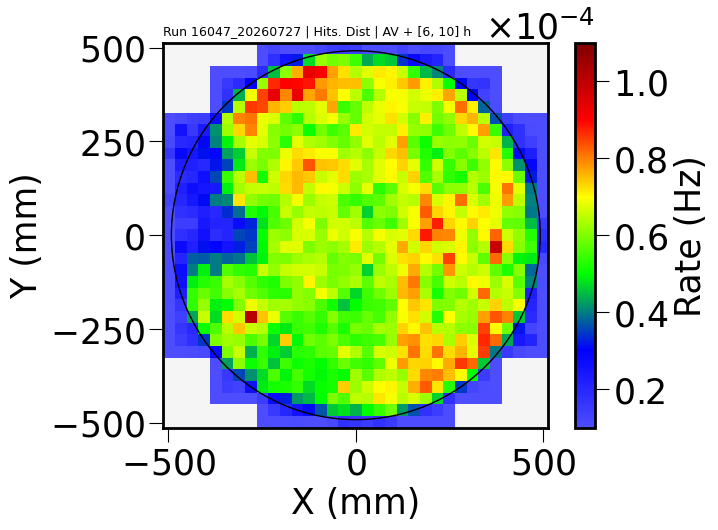


Run 16057_20260727:


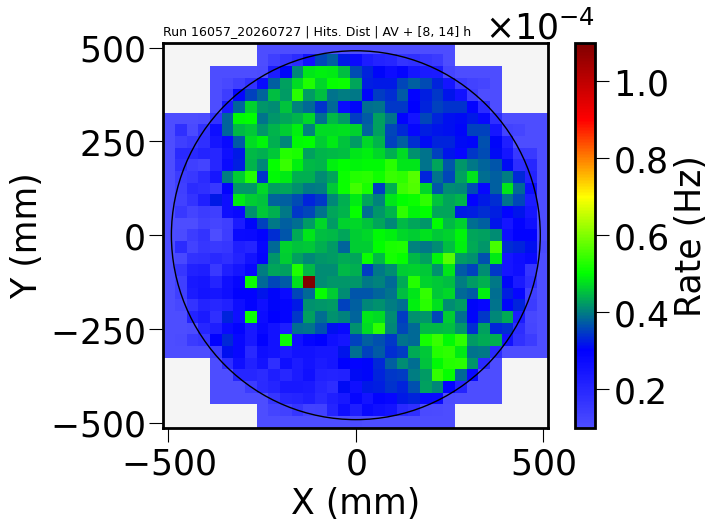

In [59]:
times_47 = [6, 10]
times_57 = [8, 14]

for key in SEL_DICT.keys():

    print(f"\nRun {key}:")
    soph_df = SEL_DICT[key]['soph_df']

    # Variables  
    X = soph_df['X']
    Y = soph_df['Y']
    Z = soph_df['Z']
    time = ((soph_df['time'] - soph_df['time'].min()) / 3600).astype(int)

    if   key == '16047_20260727': t_min, t_max = times_47
    elif key == '16057_20260727': t_min, t_max = times_57

    # Masking
    mask = (Z >= 0) & (Z <= EXTRA_INFO[key]['cath_lim']) & (time >= t_min) & (time <= t_max)
    X_mask = X[mask]
    Y_mask = Y[mask]

    # Map
    xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=2, max_limit=crudo.pt.N100_rad, pos=True, norm=True)
    xy_map = xy_map / ((t_max - t_min) * 3600)      # Normalize by time interval to get rate
    xy_map = np.ma.masked_where(xy_map==0, xy_map)

    # Plot
    plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto', vmin=0.1e-4, vmax=1.1e-4)
    plt.colorbar(label='Rate (Hz)', shrink=1.0)
    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')
    plt.title (f'Run {key} | Hits. Dist | AV + [{t_min}, {t_max}] h', loc='left', fontsize=9) 

    plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().set_facecolor("whitesmoke")
    plt.show()